# The Geometry of Linear Systems

**This notebook teaches linear systems from scratch, no prior exposure is assumed.**

A pharmacy stocks a strong drug solution and a weak one and needs a certain volume at an in-between strength: how much of each should it draw? Two unknowns, two facts about them, and the answer is the one pair of amounts that satisfies **both** facts at once. That is a **system of linear equations**, and this notebook is about what such a system *looks like*. Each equation in two unknowns draws a **line**; solving the system means finding where the lines **cross**. Whether they cross once, never, or everywhere is exactly the difference between a system having **one**, **no**, or **infinitely many** solutions. With three unknowns each equation becomes a **plane** in space, and the same three outcomes appear in ways a whiteboard cannot draw but a rotatable 3-D plot can.

## Learning objectives

- See a linear equation as a **line** (two variables) or a **plane** (three variables).
- Interpret a system of equations as the **intersection** of those lines or planes.
- Classify a two-variable system as having **one, no, or infinitely many** solutions from its slopes, before solving it.
- Solve small systems with `np.linalg.solve` and **check** the answer against every original equation.
- Recognize the three outcomes in three dimensions, including the several different ways three planes can fail to share a point.

## Background

A **linear equation** in two variables has the form $ax + by = c$ with fixed numbers $a$, $b$, $c$. Solving it for $y$ gives the **slope-intercept form** $y = mx + b$ from Unit 1: a line with slope $m$ (rise per unit of run) and $y$-intercept $b$ (where it crosses the $y$-axis). A **point** in the plane is written as a pair $(x, y)$, and a point *satisfies* an equation when plugging its coordinates in makes both sides equal. Everything below builds on just that.

## This notebook covers

1. A linear equation as a line.
2. A system as an intersection: the three cases, drawn and annotated.
3. Solving some systems, and checking the answers.
4. Three variables: planes in 3-D, all the cases, rotatable.

**Prerequisites:** `U1-3_Functions-1_DomainRangeAndFamilies` (linear functions and the slope-intercept form). This notebook opens Unit 2.

**Dataset:** none, coefficients are entered directly.

**References:** [NumPy `linalg.solve`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.solve.html), [matplotlib 3-D plotting](https://matplotlib.org/stable/gallery/mplot3d/index.html)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D     # noqa: F401  (registers the 3d projection)
from matplotlib.patches import Patch
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers


# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel('x', loc='right')
    ax.set_ylabel('y', loc='top', rotation=0)


# --- backend policy: inline everywhere, qt only for the rotatable 3-D figure in section 4 ---
def interactive_3d():
    '''Send the next figure to a draggable qt window.'''
    try:
        get_ipython().run_line_magic('matplotlib', 'qt')
    except Exception as err:
        print(f'qt backend unavailable ({err}); drawing inline instead, so no dragging.')


def static_plots():
    '''Back to inline figures. NOTE: this closes any open qt window.'''
    get_ipython().run_line_magic('matplotlib', 'inline')


static_plots()          # inline is the default for everything below

## 1. A linear equation is a line

Take the equation

$$2x + y = 11.$$

It has two unknowns and one constraint, so it does not pin down a single answer. Pick any $x$ you like, say $x = 1$, and the equation tells you $y = 11 - 2(1) = 9$. Pick $x = 3$ and it says $y = 5$. Every choice of $x$ produces exactly one $y$, so the equation has **infinitely many solutions**, one for each $x$. Plotting them all traces a straight line.

That is the general fact. Solving $ax + by = c$ for $y$ (when $b \neq 0$) gives

$$y = \frac{c - a x}{b} = -\frac{a}{b}\,x + \frac{c}{b},$$

which is the slope-intercept form $y = mx + b$ with **slope** $m = -a/b$ and **intercept** $c/b$. The equation *is* the line: every point on the line satisfies the equation, and every pair that satisfies the equation lies on the line.

Before drawing anything we need two small tools that the whole notebook will reuse: one that writes an equation as readable text from its coefficients (so a label can never disagree with the numbers that drew the line), and one that draws the line $ax + by = c$ with its equation written along it.

In [2]:
def equation_text(coefs, rhs, names=('x', 'y', 'z')):
    '''Write a1*x + a2*y (+ a3*z) = rhs as text, e.g. "2x + y = 11" or "x - 3z = 0".'''
    parts = []
    for coef, name in zip(coefs, names):
        if coef == 0:
            continue                                        # a missing variable is simply absent
        magnitude = '' if abs(coef) == 1 else f'{abs(coef):g}'
        parts.append(('-' if coef < 0 else '+', f'{magnitude}{name}'))
    text = ('-' if parts[0][0] == '-' else '') + parts[0][1]
    for sign, term in parts[1:]:
        text += f' {sign} {term}'
    return f'{text} = {rhs:g}'


def plot_line(ax, a, b, c, color, x_range=(-2, 8), label_at=None, note='', names=('x', 'y'), **style):
    '''Draw the line a*x + b*y = c, and write its equation on the line, centered at x = label_at.'''
    x = np.linspace(*x_range, 200)
    y = (c - a * x) / b                                     # solve the equation for y
    ax.plot(x, y, color=color, **{'lw': 2, **style})
    if label_at is not None:
        angle = math.degrees(math.atan2(-a, b))             # direction of the line, slope = -a/b
        if angle > 90:  angle -= 180                        # keep the text readable, never upside down
        if angle < -90: angle += 180
        text = equation_text((a, b), c, names) + (f'   ({note})' if note else '')
        ax.text(label_at, (c - a * label_at) / b, text, color=color, fontsize=10,
                rotation=angle, rotation_mode='anchor', transform_rotates_text=True,
                ha='center', va='center', bbox=dict(fc='black', ec='none', pad=1.5))   # sits on the line


def mark_point(ax, point, color='white', offset=(0.5, 0.6), text=None):
    '''Dot a point and label it with its coordinates (rounded), arrow pointing at it.'''
    px, py = point
    label = text if text is not None else f'({px:.3g}, {py:.3g})'
    ax.plot(px, py, 'o', color=color, ms=7, zorder=5)
    ax.annotate(label, xy=(px, py), xytext=(px + offset[0], py + offset[1]),
                color=color, fontsize=11, arrowprops=dict(arrowstyle='->', color=color))

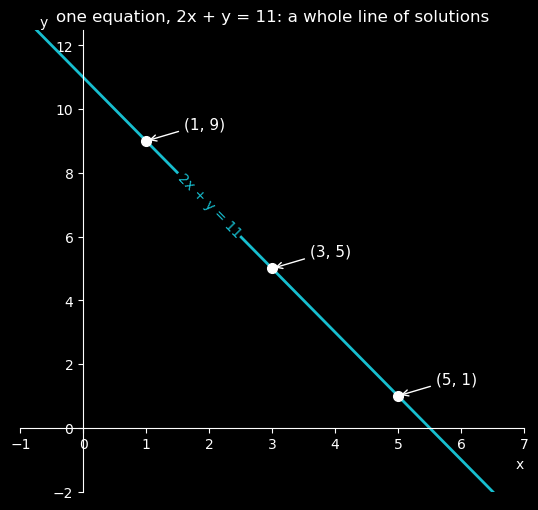

In [3]:
a, b, c = 2, 1, 11                          # the equation 2x + y = 11

fig, ax = plt.subplots(figsize=(6.5, 6))
plot_line(ax, a, b, c, 'tab:cyan', x_range=(-1, 7), label_at=2.0)

# three of its infinitely many solutions: choose x, the equation hands back y
for x_choice in (1, 3, 5):
    y_choice = (c - a * x_choice) / b
    mark_point(ax, (x_choice, y_choice), offset=(0.6, 0.4))

center_axes(ax)
ax.set_xlim(-1, 7); ax.set_ylim(-2, 12.5)
ax.set_title(f'one equation, {equation_text((a, b), c)}: a whole line of solutions')
plt.show()

The three marked points are just three of the line's infinitely many solutions. A single equation in two unknowns is **underdetermined**: it narrows the possibilities down to a line, but no further. To pin down one point we need a second equation.

## 2. A system is an intersection: the three cases

A **system** is two or more equations that must hold **at the same time**. A **solution of the system** is a point that satisfies *every* equation, so it must lie on *every* line. Geometrically:

> **Solving a two-variable system means finding where the lines intersect.**

Two lines in a plane can do only three things: cross at one point, run parallel without ever meeting, or be the very same line. Those three pictures are the three possible outcomes for a system, and there is no fourth, because two distinct lines cannot cross twice.

### 2.1 Case 1: the lines cross once (exactly one solution)

$$\left\{\begin{aligned} 2x + y &= 11 \\ x + 3y &= 18 \end{aligned}\right.$$

The slopes are $-2$ and $-\tfrac{1}{3}$. Different slopes means the lines are not parallel, so they must cross somewhere, and a point on both lines is a solution of both equations. Such a system is called **consistent** (it has a solution) and **independent** (neither equation is a rewording of the other).

To *find* the crossing we hand the coefficients and right-hand sides to `np.linalg.solve`, which is the one tool this notebook borrows from later in the unit. The next two notebooks (`U2-1_Systems-2` and `U2-1_Systems-3`) show what it does by hand; here we only need its answer. Whatever produces an answer, **check it in both original equations**: it costs ten seconds and catches most mistakes.

In [4]:
# each equation is (a, b) on the left and c on the right:  a*x + b*y = c
coefficients    = np.array([[2.0, 1.0],
                            [1.0, 3.0]])
right_hand_side = np.array([11.0, 18.0])

solution = np.linalg.solve(coefficients, right_hand_side)
helpers.show(solution, label='the crossing point (x, y)')

# check: plug the point back into each ORIGINAL equation
for (a, b), c in zip(coefficients, right_hand_side):
    value = a * solution[0] + b * solution[1]
    print(f'{equation_text((a, b), c):>14}:   left side = {value:.3g}   (should be {c:g})')

<IPython.core.display.Math object>

   2x + y = 11:   left side = 11   (should be 11)
   x + 3y = 18:   left side = 18   (should be 18)


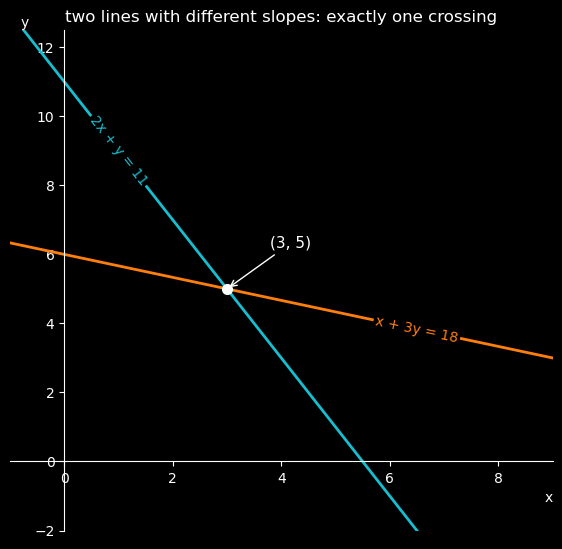

In [5]:
fig, ax = plt.subplots(figsize=(7, 6.5))
plot_line(ax, 2, 1, 11, 'tab:cyan',   x_range=(-1, 7), label_at=1.0)
plot_line(ax, 1, 3, 18, 'tab:orange', x_range=(-1, 9), label_at=6.5)
mark_point(ax, solution, offset=(0.8, 1.2))

center_axes(ax)
ax.set_xlim(-1, 9); ax.set_ylim(-2, 12.5)
ax.set_title('two lines with different slopes: exactly one crossing')
plt.show()

### 2.2 Case 2: the lines are parallel (no solution)

$$\left\{\begin{aligned} x + 2y &= 4 \\ 2x + 4y &= 14 \end{aligned}\right.$$

Look at the left-hand sides: $2x + 4y$ is exactly twice $x + 2y$. If both equations held, doubling the first would give $2x + 4y = 8$, but the second insists $2x + 4y = 14$. So $8 = 14$, which is false, and **no point can satisfy both**. The system is **inconsistent**.

In the picture, both lines have slope $-\tfrac{1}{2}$ but different intercepts ($2$ and $\tfrac{7}{2}$): they are parallel and never meet. `np.linalg.solve` cannot return a point that does not exist, so it raises an error instead. We catch the error and print it, because the message is worth reading.

np.linalg.solve refused: "Singular matrix"


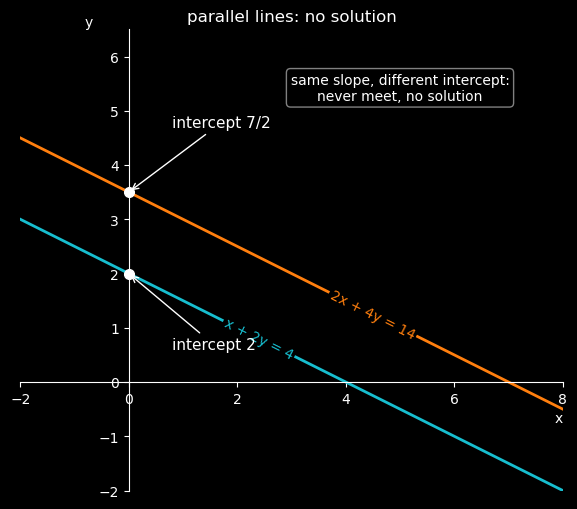

In [6]:
coefficients    = np.array([[1.0, 2.0],
                            [2.0, 4.0]])
right_hand_side = np.array([4.0, 14.0])

try:
    solution = np.linalg.solve(coefficients, right_hand_side)
    helpers.show(solution, label='solution')
except np.linalg.LinAlgError as err:
    print(f'np.linalg.solve refused: "{err}"')

fig, ax = plt.subplots(figsize=(7, 6))
plot_line(ax, 1, 2, 4,  'tab:cyan',   x_range=(-2, 8), label_at=2.4)
plot_line(ax, 2, 4, 14, 'tab:orange', x_range=(-2, 8), label_at=4.5)

# the two y-intercepts, to show the lines are offset copies of each other
mark_point(ax, (0, 4 / 2),  offset=(0.8, -1.4), text='intercept 2')
mark_point(ax, (0, 14 / 4), offset=(0.8, 1.2),  text='intercept 7/2')
ax.text(5.0, 5.2, 'same slope, different intercept:\nnever meet, no solution',
        color='white', fontsize=10, ha='center',
        bbox=dict(boxstyle='round', fc='black', ec='gray'))

center_axes(ax)
ax.set_xlim(-2, 8); ax.set_ylim(-2, 6.5); ax.set_aspect('equal')
ax.set_title('parallel lines: no solution')
plt.show()

The word in the error, **singular**, is NumPy's name for "the equations do not determine a single point". It will come back with a precise meaning in `U2-5_Determinants-2_InverseAsUndo`.

### 2.3 Case 3: the lines coincide (infinitely many solutions)

$$\left\{\begin{aligned} x + 2y &= 4 \\ 2x + 4y &= 8 \end{aligned}\right.$$

Same left-hand sides as before, but now the second right-hand side is $8$, which *is* twice $4$. The second equation is exactly twice the first: it says nothing new. The system is **dependent**, and its solutions are all the points on the one line both equations describe.

To describe infinitely many points we use a **parameter**: let $y = t$ be anything, then the first equation gives $x = 4 - 2t$, so every solution has the form

$$(x, y) = (4 - 2t,\; t) \qquad \text{for every real number } t.$$

Setting $t = 0, 1, 2$ gives $(4, 0)$, $(2, 1)$, $(0, 2)$, all of which lie on the line. Once again `np.linalg.solve` refuses, with the **same** message as the parallel case: from its point of view "no solution" and "infinitely many" look alike. Telling those two apart is a job for Gaussian elimination in `U2-1_Systems-3_GaussianElimination`.

np.linalg.solve refused: "Singular matrix"


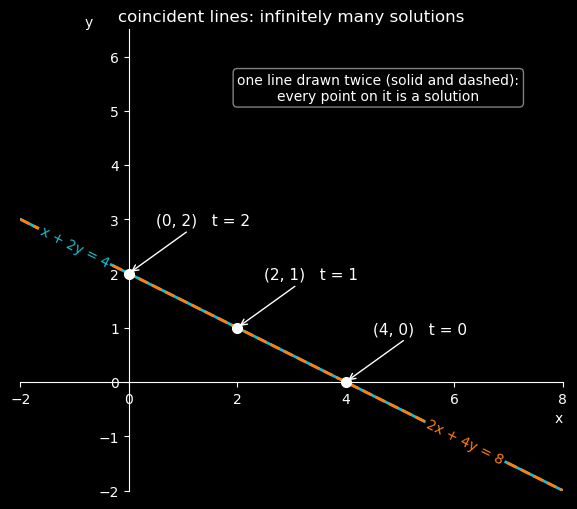

In [7]:
coefficients    = np.array([[1.0, 2.0],
                            [2.0, 4.0]])
right_hand_side = np.array([4.0, 8.0])

try:
    solution = np.linalg.solve(coefficients, right_hand_side)
    helpers.show(solution, label='solution')
except np.linalg.LinAlgError as err:
    print(f'np.linalg.solve refused: "{err}"')

fig, ax = plt.subplots(figsize=(7, 6))
plot_line(ax, 1, 2, 4, 'tab:cyan',   x_range=(-2, 8), label_at=-1.0)                  # solid, underneath
plot_line(ax, 2, 4, 8, 'tab:orange', x_range=(-2, 8), label_at=6.2, ls='--')           # dashed, on top: same line

for t in (0, 1, 2):                          # three of the infinitely many solutions
    mark_point(ax, (4 - 2 * t, t), offset=(0.5, 0.9), text=f'({4 - 2 * t}, {t})   t = {t}')
ax.text(4.6, 5.2, 'one line drawn twice (solid and dashed):\nevery point on it is a solution',
        color='white', fontsize=10, ha='center',
        bbox=dict(boxstyle='round', fc='black', ec='gray'))

center_axes(ax)
ax.set_xlim(-2, 8); ax.set_ylim(-2, 6.5); ax.set_aspect('equal')
ax.set_title('coincident lines: infinitely many solutions')
plt.show()

### 2.4 The three cases side by side

Notice how little separates cases 2 and 3: the left-hand sides are identical, and only the right-hand side decides whether the lines are parallel or the same. Here are all three at once, each with its crossing (or lack of one) marked. This is the picture to carry in your head for the rest of the unit.

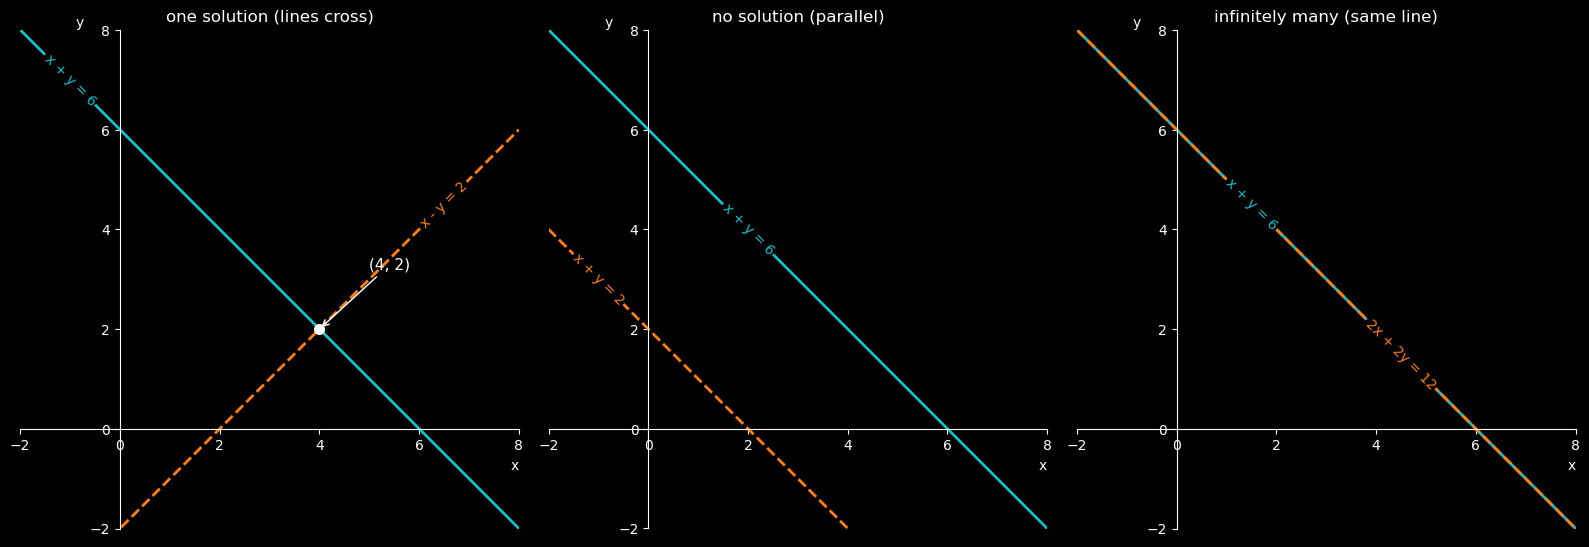

In [8]:
# each case: a title, equation 1, equation 2, and where along x to write each label
cases_2d = [
    ('one solution (lines cross)',   (1, 1, 6), (1, -1, 2),  (-1.0, 6.5)),
    ('no solution (parallel)',       (1, 1, 6), (1, 1, 2),   (2.0, -1.0)),
    ('infinitely many (same line)',  (1, 1, 6), (2, 2, 12),  (1.5, 4.5)),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5.6))
for ax, (title, eq1, eq2, (at1, at2)) in zip(axes, cases_2d):
    plot_line(ax, *eq1, 'tab:cyan',   x_range=(-2, 8), label_at=at1)
    plot_line(ax, *eq2, 'tab:orange', x_range=(-2, 8), label_at=at2, ls='--')
    try:
        crossing = np.linalg.solve([eq1[:2], eq2[:2]], [eq1[2], eq2[2]])
        mark_point(ax, crossing, offset=(1.0, 1.2))
    except np.linalg.LinAlgError:
        pass                                    # nothing to mark: no single crossing point
    center_axes(ax)
    ax.set_xlim(-2, 8); ax.set_ylim(-2, 8); ax.set_aspect('equal')
    ax.set_title(title)
plt.tight_layout()
plt.show()

### 2.5 Telling the cases apart before you solve

The pictures suggest a test that needs no drawing. Write both equations in slope-intercept form and compare:

- **different slopes**: the lines must cross, so exactly **one** solution;
- **same slope, different intercept**: parallel, so **no** solution;
- **same slope, same intercept**: the same line, so **infinitely many**.

For $a_1 x + b_1 y = c_1$ and $a_2 x + b_2 y = c_2$ the slopes are $-a_1/b_1$ and $-a_2/b_2$. Setting them equal and cross-multiplying, the slopes match exactly when

$$a_1 b_2 = a_2 b_1,$$

which is the same as saying the left-hand sides are **proportional** (one is a multiple of the other). If they are, the lines are either parallel or identical, and the right-hand side decides which: the equations are the same line only if $c$ scales by that same multiple, that is $a_1 c_2 = a_2 c_1$ and $b_1 c_2 = b_2 c_1$ as well. That version of the test, "is one whole equation a multiple of the other?", is the one that survives into three and more variables, where there is no single slope to compare.

In [9]:
def classify(eq1, eq2):
    '''How many solutions does the pair a1*x + b1*y = c1, a2*x + b2*y = c2 have?'''
    (a1, b1, c1), (a2, b2, c2) = eq1, eq2
    left_sides_proportional = np.isclose(a1 * b2, a2 * b1)               # same slope?
    whole_eqs_proportional  = left_sides_proportional and np.isclose(a1 * c2, a2 * c1) \
                                                       and np.isclose(b1 * c2, b2 * c1)
    if not left_sides_proportional:
        return 'exactly one solution: different slopes, the lines cross'
    if whole_eqs_proportional:
        return 'infinitely many solutions: one equation is a multiple of the other, same line'
    return 'no solution: same slope but different intercept, parallel lines'


for title, eq1, eq2, _ in cases_2d:
    print(f'{equation_text(eq1[:2], eq1[2]):>12}  and  {equation_text(eq2[:2], eq2[2]):<12} ->  {classify(eq1, eq2)}')

   x + y = 6  and  x - y = 2    ->  exactly one solution: different slopes, the lines cross
   x + y = 6  and  x + y = 2    ->  no solution: same slope but different intercept, parallel lines
   x + y = 6  and  2x + 2y = 12 ->  infinitely many solutions: one equation is a multiple of the other, same line


## 3. Solving some systems

Time to use all of this on actual questions. Each one is set up in words, turned into equations, classified, solved, checked, and drawn.

### 3.1 Mixing two stock solutions

> *The pharmacy stocks a 10 mg/mL drug solution and a 2 mg/mL solution. We need 500 mL at 4 mg/mL. How much of each do we draw?*

Two things are unknown, so name them both: let $x$ be the mL of the **strong** solution and $y$ the mL of the **weak** one. Two facts constrain them:

$$\begin{aligned}
\text{the volumes must total 500 mL:} \qquad x + y &= 500 \\
\text{the drug must total } 4 \times 500 = 2000 \text{ mg:} \qquad 10x + 2y &= 2000
\end{aligned}$$

Neither equation is solvable on its own; together they pin down one pair. By hand, isolate $y = 500 - x$ from the first equation and substitute it into the second: $10x + 2(500 - x) = 2000$, so $8x = 1000$ and $x = 125$, then $y = 375$. Let the computer confirm it.

In [10]:
coefficients    = np.array([[1.0,  1.0],        # x +  y  = 500
                            [10.0, 2.0]])       # 10x + 2y = 2000
right_hand_side = np.array([500.0, 2000.0])

print(classify((1, 1, 500), (10, 2, 2000)))

amounts = np.linalg.solve(coefficients, right_hand_side)
helpers.show(amounts, label='(x, y) in mL')
print(f'draw {amounts[0]:.0f} mL of the 10 mg/mL stock and {amounts[1]:.0f} mL of the 2 mg/mL stock')

# the check, phrased in the units of the problem
total_volume = amounts[0] + amounts[1]
total_drug   = 10 * amounts[0] + 2 * amounts[1]
print(f'check: volume {total_volume:.0f} mL, drug {total_drug:.0f} mg, strength {total_drug / total_volume:.2f} mg/mL')

exactly one solution: different slopes, the lines cross


<IPython.core.display.Math object>

draw 125 mL of the 10 mg/mL stock and 375 mL of the 2 mg/mL stock
check: volume 500 mL, drug 2000 mg, strength 4.00 mg/mL


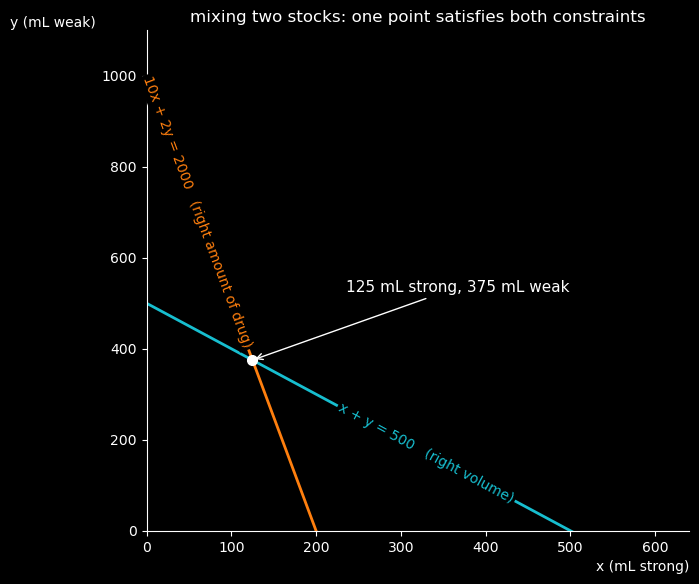

In [11]:
fig, ax = plt.subplots(figsize=(7, 6.5))
plot_line(ax, 1, 1, 500,   'tab:cyan',   x_range=(0, 600), label_at=330, note='right volume')
plot_line(ax, 10, 2, 2000, 'tab:orange', x_range=(0, 200), label_at=60,  note='right amount of drug')
mark_point(ax, amounts, offset=(110, 150), text=f'{amounts[0]:.0f} mL strong, {amounts[1]:.0f} mL weak')

center_axes(ax)
ax.set_xlabel('x (mL strong)', loc='right')
ax.set_ylabel('y (mL weak)', loc='top', rotation=0)
ax.set_xlim(0, 640); ax.set_ylim(0, 1100)
ax.set_title('mixing two stocks: one point satisfies both constraints')
plt.show()

Every point on the cyan line is a mix with the right **volume**; every point on the orange line is a mix with the right **amount of drug**. Only the crossing has both, which is why a mixing question with two unknowns needs two facts.

### 3.2 Classify, then solve the one you can

Three systems, each to be classified from the slopes alone. The first is given in slope-intercept form, $y = 2x + 1$ and $y = 2x - 3$; moving the $x$ term across turns those into $-2x + y = 1$ and $-2x + y = -3$, which is the $ax + by = c$ shape our tools expect.

$$
1.\ \left\{\begin{aligned} y &= 2x + 1 \\ y &= 2x - 3 \end{aligned}\right.
\qquad
2.\ \left\{\begin{aligned} 2x + 4y &= 8 \\ x + 2y &= 4 \end{aligned}\right.
\qquad
3.\ \left\{\begin{aligned} x + y &= 2 \\ x - y &= 0 \end{aligned}\right.
$$

system 1: no solution: same slope but different intercept, parallel lines
system 2: infinitely many solutions: one equation is a multiple of the other, same line
system 3: exactly one solution: different slopes, the lines cross


<IPython.core.display.Math object>

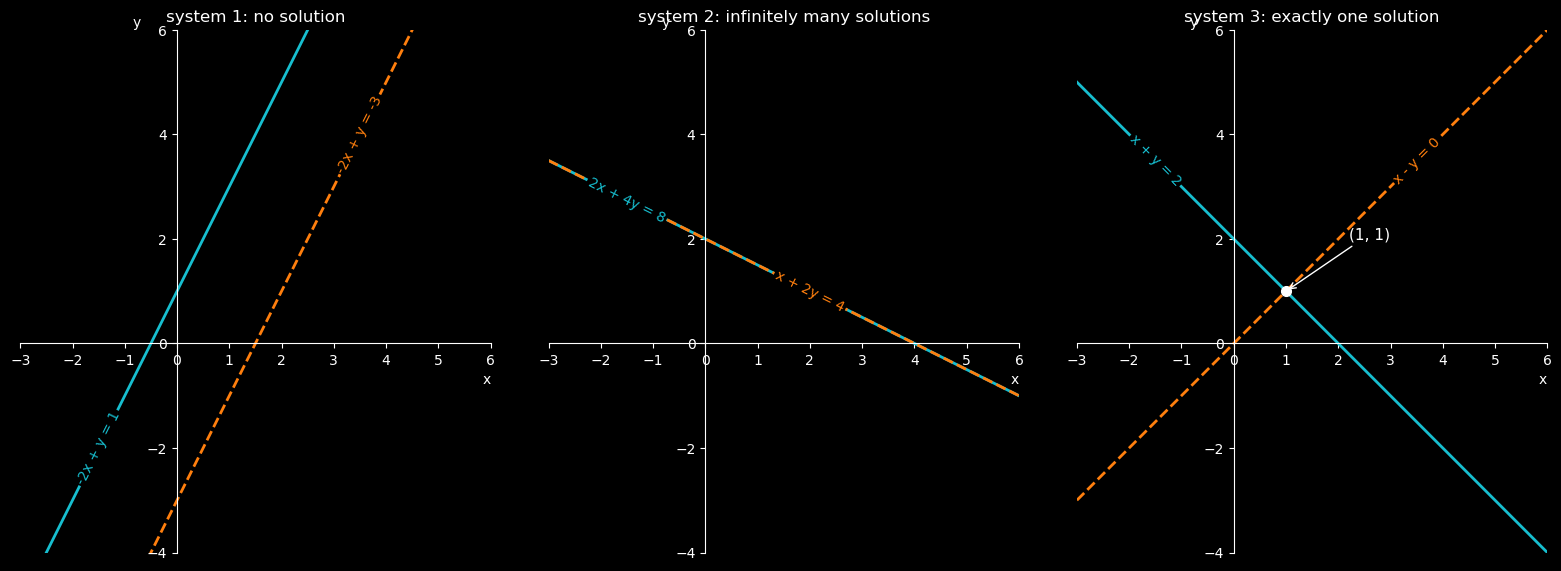

In [12]:
exercise = [
    ('system 1', (-2, 1, 1),  (-2, 1, -3),  (-1.5, 3.5)),
    ('system 2', (2, 4, 8),   (1, 2, 4),    (-1.5, 2.0)),
    ('system 3', (1, 1, 2),   (1, -1, 0),   (-1.5, 3.5)),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5.6))
for ax, (name, eq1, eq2, (at1, at2)) in zip(axes, exercise):
    verdict = classify(eq1, eq2)
    print(f'{name}: {verdict}')

    plot_line(ax, *eq1, 'tab:cyan',   x_range=(-3, 6), label_at=at1)
    plot_line(ax, *eq2, 'tab:orange', x_range=(-3, 6), label_at=at2, ls='--')
    if verdict.startswith('exactly one'):
        point = np.linalg.solve([eq1[:2], eq2[:2]], [eq1[2], eq2[2]])
        helpers.show(point, label=f'{name} solution (x, y)')
        mark_point(ax, point, offset=(1.2, 1.0))
    center_axes(ax)
    ax.set_xlim(-3, 6); ax.set_ylim(-4, 6); ax.set_aspect('equal')
    ax.set_title(f'{name}: {verdict.split(":")[0]}')
plt.tight_layout()
plt.show()

System 3 is the one with a single answer: adding its two equations gives $2x = 2$, so $x = 1$ and then $y = 1$, which is the marked crossing, and it checks in both equations ($1 + 1 = 2$, $1 - 1 = 0$). Systems 1 and 2 have identical left-hand sides up to a factor, and only their right-hand sides put them in different cases.

### 3.3 A line through two points is a system

Here is a system that does not look like one at first. Suppose we want the straight line $y = mx + b$ that passes through the two data points $(1, 3)$ and $(4, 9)$. The **unknowns** are now the slope $m$ and intercept $b$, and each point the line must pass through contributes one equation:

$$\begin{aligned}
\text{through } (1, 3):& \qquad m \cdot 1 + b = 3 \\
\text{through } (4, 9):& \qquad m \cdot 4 + b = 9
\end{aligned}$$

Two linear equations in the unknowns $m$ and $b$. The left panel below shows the data and the fitted line in the usual $x$-$y$ plane; the right panel shows the **same problem** as two lines crossing in the $m$-$b$ plane, where every point on a line is a $(m, b)$ pair whose line passes through one of the data points. The crossing is the one $(m, b)$ that passes through both. Fitting a model *is* solving a system, and Unit 3 will build regression on exactly this idea.

the line through both points is  y = 2x + 1
check (1, 3):  2*1 + 1 = 3
check (4, 9):  2*4 + 1 = 9


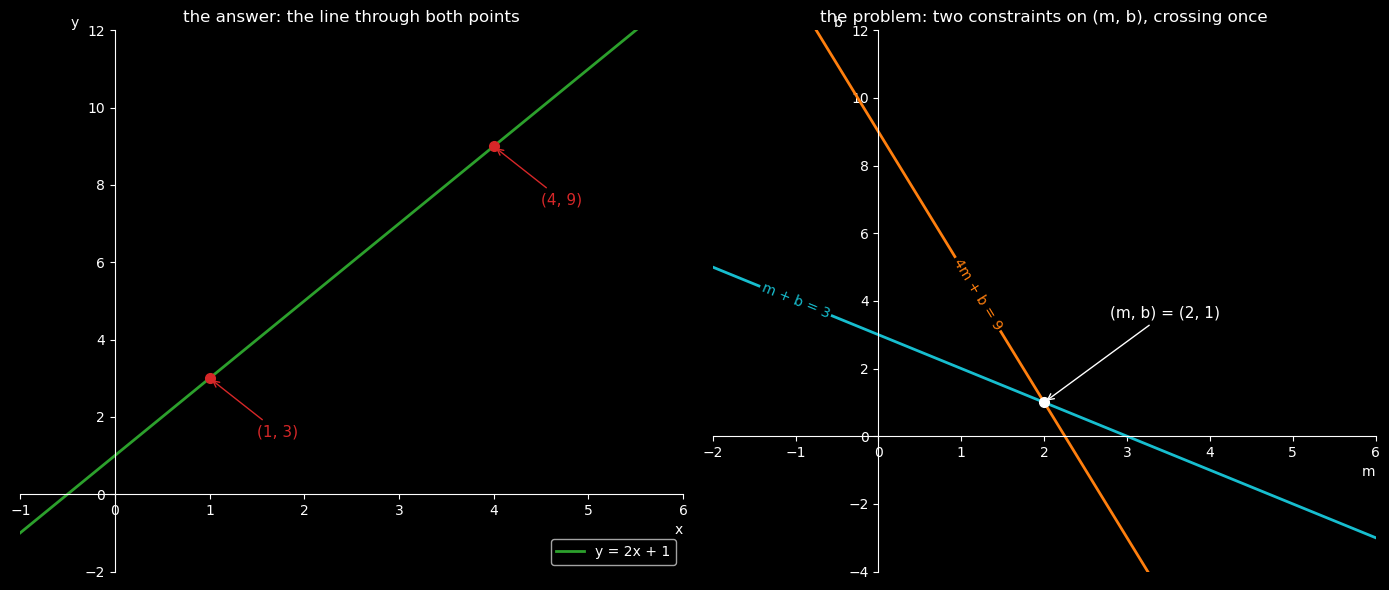

In [13]:
points = np.array([[1.0, 3.0],
                   [4.0, 9.0]])                 # the two data points (x, y)

# one row per point: m*x + b*1 = y
coefficients    = np.array([[points[0, 0], 1.0],
                            [points[1, 0], 1.0]])
right_hand_side = points[:, 1]

m, b = np.linalg.solve(coefficients, right_hand_side)
print(f'the line through both points is  y = {m:.3g}x + {b:.3g}')
for x_pt, y_pt in points:
    print(f'check ({x_pt:g}, {y_pt:g}):  {m:.3g}*{x_pt:g} + {b:.3g} = {m * x_pt + b:.3g}')

fig, (ax_xy, ax_mb) = plt.subplots(1, 2, figsize=(14, 6))

# left: the data and the fitted line, in the x-y plane
xs = np.linspace(-1, 6, 100)
ax_xy.plot(xs, m * xs + b, color='tab:green', lw=2, label=f'y = {m:.3g}x + {b:.3g}')
for x_pt, y_pt in points:
    mark_point(ax_xy, (x_pt, y_pt), color='tab:red', offset=(0.5, -1.5))
center_axes(ax_xy)
ax_xy.set_xlim(-1, 6); ax_xy.set_ylim(-2, 12)
ax_xy.legend(loc='lower right'); ax_xy.set_title('the answer: the line through both points')

# right: the same problem as a system in the unknowns (m, b), so the equations are written in m and b
plot_line(ax_mb, points[0, 0], 1, points[0, 1], 'tab:cyan',   x_range=(-2, 6), label_at=-1.0, names=('m', 'b'))
plot_line(ax_mb, points[1, 0], 1, points[1, 1], 'tab:orange', x_range=(-2, 6), label_at=1.2,  names=('m', 'b'))
mark_point(ax_mb, (m, b), offset=(0.8, 2.5), text=f'(m, b) = ({m:.3g}, {b:.3g})')
center_axes(ax_mb)
ax_mb.set_xlabel('m', loc='right'); ax_mb.set_ylabel('b', loc='top', rotation=0)
ax_mb.set_xlim(-2, 6); ax_mb.set_ylim(-4, 12)
ax_mb.set_title('the problem: two constraints on (m, b), crossing once')
plt.tight_layout()
plt.show()

In the right-hand panel the axes are $m$ and $b$, not $x$ and $y$: the cyan line is every $(m, b)$ with $m + b = 3$, every line through $(1, 3)$. Two data points give two constraints, and two lines in the $(m, b)$ plane cross once, so exactly one line passes through both points. (Three data points would give three constraints, and three lines in a plane usually do **not** share a point: that is why real data needs least squares, coming in Unit 3.)

## 4. Three variables: planes in 3-D

### 4.1 One equation in three variables is a plane

With three unknowns, an equation like

$$x + y + z = 6$$

still has infinitely many solutions, but now you get to choose *two* of the variables freely and the equation hands back the third: pick any $x$ and $y$, then $z = 6 - x - y$. Two free choices means the solutions fill a flat two-dimensional sheet floating in space, a **plane**. The easiest points to find on it are the three **intercepts**, where the plane crosses each axis: $(6, 0, 0)$, $(0, 6, 0)$, and $(0, 0, 6)$.

A plane goes on forever, so to draw one we show only the piece that fits inside a box around the origin. The helper below finds where the plane cuts the box's edges and fills in the flat patch between those cut points; it is graphics only, nothing in it needs reading, and it is reused for every 3-D figure in this section. The axes are drawn through the origin, as in the 2-D plots.

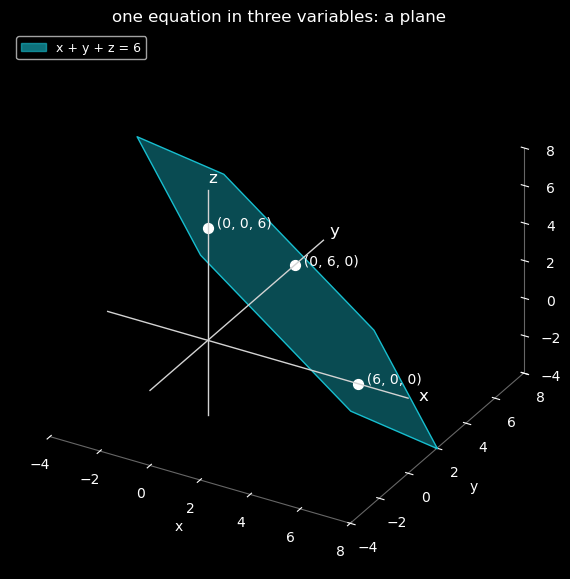

In [14]:
# ----- graphics helpers for the 3-D figures: nothing here needs reading -----
BOX = (-4, 8)                                   # every 3-D picture shows this cube
PLANE_COLORS = ['tab:cyan', 'tab:orange', 'tab:green']


def plane_patch(a, b, c, d, box=BOX):
    '''Corners of the piece of the plane a*x + b*y + c*z = d that lies inside the cube.'''
    lo, hi = box
    corners = np.array([[x, y, z] for x in (lo, hi) for y in (lo, hi) for z in (lo, hi)], dtype=float)
    height = corners[:, 0] * a + corners[:, 1] * b + corners[:, 2] * c - d     # 0 exactly on the plane
    points = list(corners[height == 0])
    for i in range(8):                                                         # each cube edge that the plane cuts
        for j in range(i + 1, 8):
            if np.sum(corners[i] != corners[j]) == 1 and height[i] * height[j] < 0:
                frac = height[i] / (height[i] - height[j])
                points.append(corners[i] + frac * (corners[j] - corners[i]))
    if len(points) < 3:
        return None                                                            # the plane misses the cube
    points = np.unique(np.round(np.array(points), 9), axis=0)
    flat = np.argsort(np.abs([a, b, c]))[:2]                                   # two axes the patch is least steep along
    center = points.mean(axis=0)
    order = np.argsort(np.arctan2(points[:, flat[1]] - center[flat[1]], points[:, flat[0]] - center[flat[0]]))
    return points[order]                                                       # corners walked around the patch


def clip_to_box(pts, box=BOX):
    '''Blank out any points outside the cube so a line stops at the box instead of running off.'''
    lo, hi = box
    pts = pts.astype(float).copy()
    pts[np.any((pts < lo) | (pts > hi), axis=1)] = np.nan
    return pts


def setup_3d(ax, box=BOX, title=''):
    '''Black panes, no grid, x-y-z axes drawn through the origin, no perspective.'''
    lo, hi = box
    ax.computed_zorder = False                             # draw things in the order they are added
    ax.set_proj_type('ortho')                              # parallel planes stay parallel on the page
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.set_pane_color((0, 0, 0, 0))
        axis.line.set_color((0.4, 0.4, 0.4))
    ax.grid(False)
    for direction, name in zip(np.eye(3), 'xyz'):        # the three axes through the origin
        start, end = lo * direction, hi * direction
        ax.plot(*zip(start, end), color='lightgray', lw=1)
        ax.text(*(end * 1.05), name, color='white', fontsize=12)
    ax.set_xlim(box); ax.set_ylim(box); ax.set_zlim(box)
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
    ax.set_title(title)


def draw_planes(ax, planes, box=BOX, title=''):
    '''Draw each plane (a, b, c, d) as a translucent patch, with a legend of the equations.'''
    setup_3d(ax, box, title)
    for (a, b, c, d), color in zip(planes, PLANE_COLORS):
        patch = plane_patch(a, b, c, d, box)
        if patch is not None:
            ax.add_collection3d(Poly3DCollection([patch], facecolor=color, edgecolor=color, alpha=0.4, lw=1))
    handles = [Patch(color=color, alpha=0.6, label=equation_text((a, b, c), d))
               for (a, b, c, d), color in zip(planes, PLANE_COLORS)]
    ax.legend(handles=handles, loc='upper left', fontsize=9)


fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(projection='3d')
draw_planes(ax, [(1, 1, 1, 6)], title='one equation in three variables: a plane')

for intercept in ([6, 0, 0], [0, 6, 0], [0, 0, 6]):        # the three axis crossings
    ax.scatter(*intercept, color='white', s=50, depthshade=False)
    ax.text(*intercept, f'  ({intercept[0]}, {intercept[1]}, {intercept[2]})', color='white', fontsize=10)
plt.show()

### 4.2 Three planes meeting at a point

A system of three equations in three unknowns asks: *where do these three planes all meet?* Take the system

$$\left\{\begin{aligned} x + y + z &= 6 \\ 2x - y + z &= 3 \\ x + 2y - z &= 2 \end{aligned}\right.$$

Two planes that are not parallel cross along a **line**; a third plane that is not parallel to that line pierces it at a single **point**. That point is the unique solution. As in two dimensions, we let `np.linalg.solve` find it and then check it in all three original equations.

<IPython.core.display.Math object>

   x + y + z = 6:   left side = 6   (should be 6)
  2x - y + z = 3:   left side = 3   (should be 3)
  x + 2y - z = 2:   left side = 2   (should be 2)


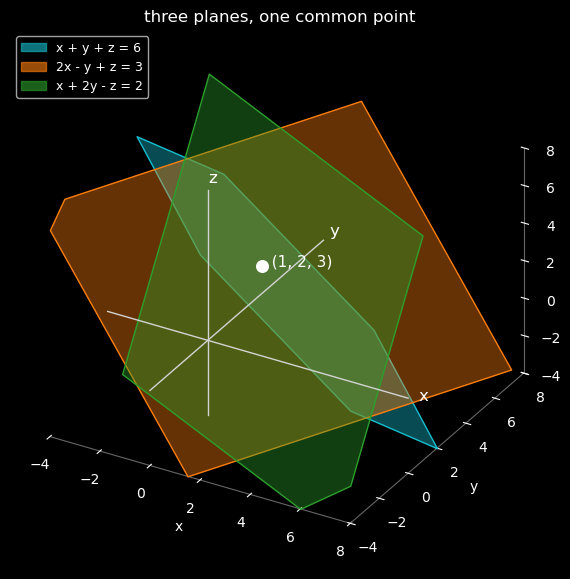

In [15]:
planes = [(1, 1, 1, 6),
          (2, -1, 1, 3),
          (1, 2, -1, 2)]

coefficients    = np.array([p[:3] for p in planes], dtype=float)
right_hand_side = np.array([p[3]  for p in planes], dtype=float)

point = np.linalg.solve(coefficients, right_hand_side)
helpers.show(point, label='where the three planes meet (x, y, z)')

for (a, b, c, d) in planes:
    value = a * point[0] + b * point[1] + c * point[2]
    print(f'{equation_text((a, b, c), d):>16}:   left side = {value:.3g}   (should be {d:g})')

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(projection='3d')
draw_planes(ax, planes, title='three planes, one common point')
ax.scatter(*point, color='white', s=70, depthshade=False)
ax.text(*point, f'  ({point[0]:.3g}, {point[1]:.3g}, {point[2]:.3g})', color='white', fontsize=11)
plt.show()

### 4.3 All the cases for three planes

In two dimensions there were three pictures. In three dimensions there are still only three **outcomes** (one solution, none, infinitely many), but each outcome can happen in more than one way, because planes have more room to arrange themselves:

| outcome | how the planes sit | how the answer looks |
|---|---|---|
| **one solution** | all three cross at a single point | a point |
| **infinitely many** | all three share a common line (like pages of an open book along its spine) | a line, described with one parameter |
| **infinitely many** | all three are the same plane | a plane, described with two parameters |
| **none** | two planes parallel, the third cuts across both | nothing |
| **none** | no two parallel, but the three pairwise crossing lines are parallel (a triangular prism) | nothing |
| **none** | all three parallel | nothing |

The prism case is the one worth staring at: every *pair* of planes crosses fine, yet no point is on all three. The gallery below draws all six. Where there is a common point or line it is drawn in white; in the prism case the three pairwise crossing lines are drawn dashed so you can see them run parallel and never meet.

The crossing line of two planes is found the same way as everything else here: treat $z$ as free, set $z = t$, and solve the remaining two equations for $x$ and $y$ with `np.linalg.solve`. For the "a line" case below, the third plane is the *sum* of the first two, so it contains everything the first two share; with $z = t$ the first two equations give $x = (11 - 3t)/2$ and $y = (1 + t)/2$, which the helper reproduces numerically.

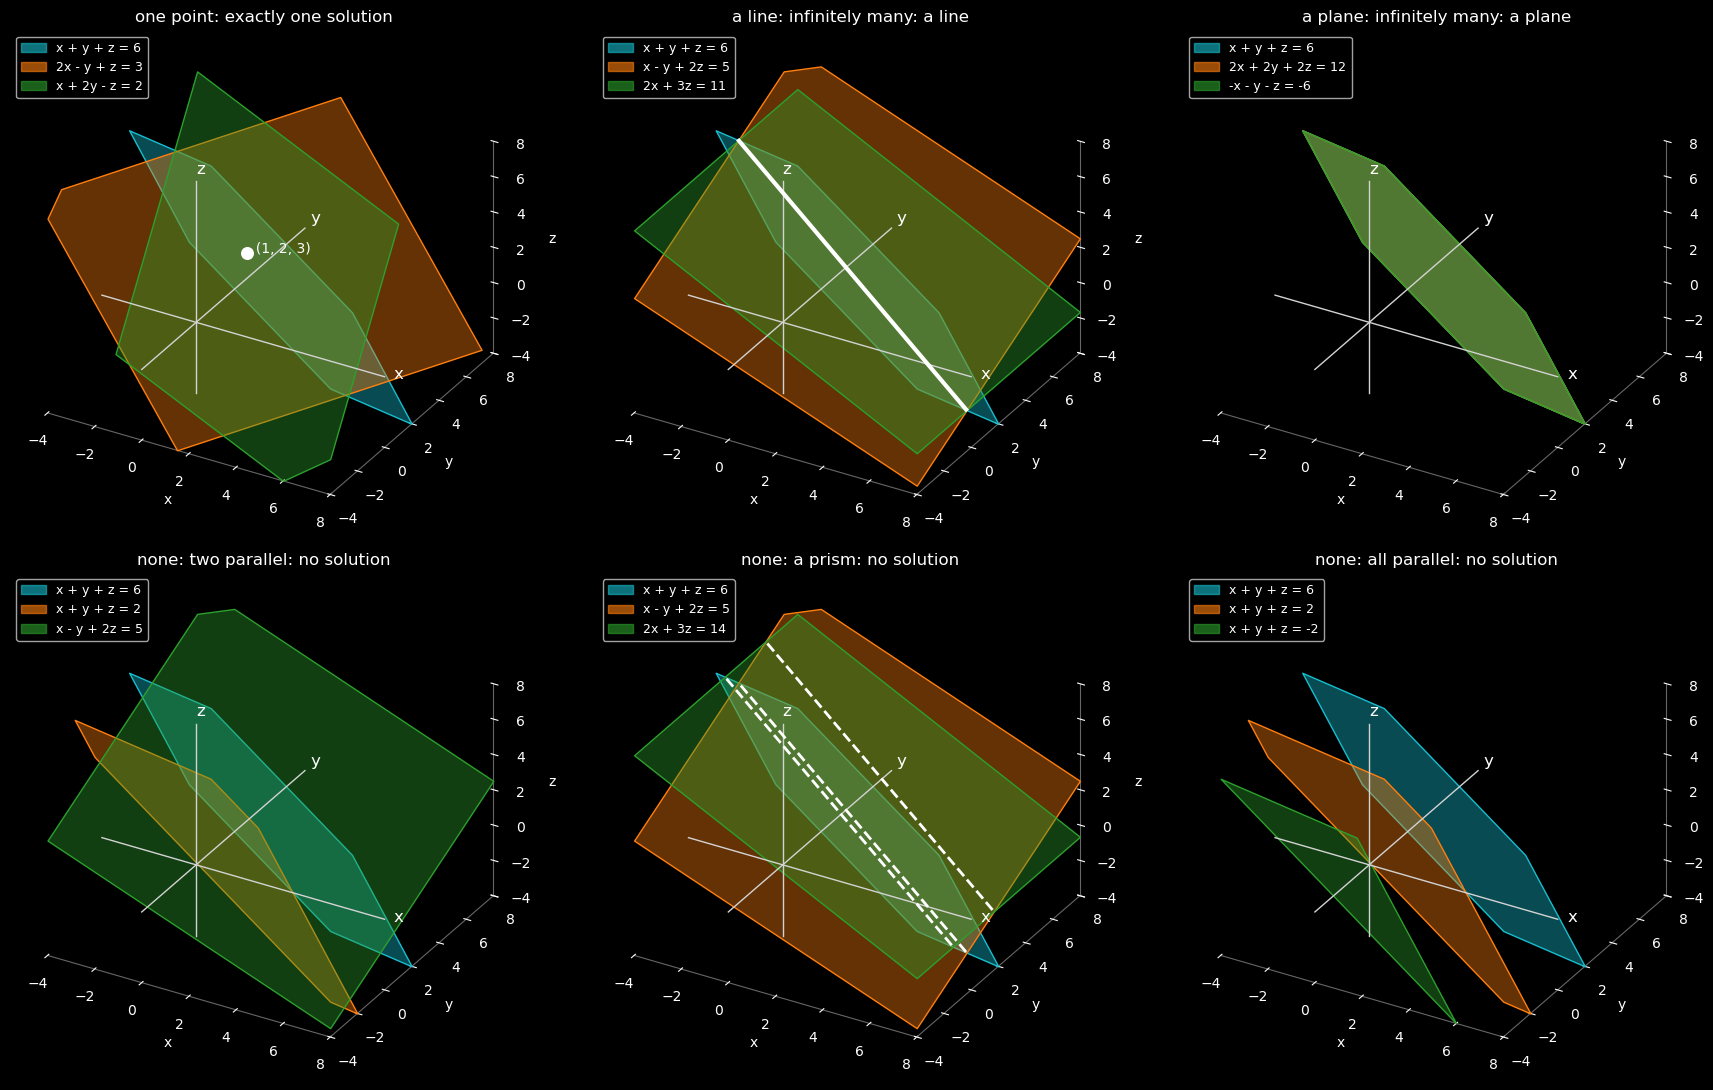

In [16]:
def line_of_two_planes(plane1, plane2, t_values):
    '''Points on the line where two planes cross: for each z = t, solve the 2x2 system for x and y.'''
    (a1, b1, c1, d1), (a2, b2, c2, d2) = plane1, plane2
    pts = []
    for t in t_values:
        x, y = np.linalg.solve([[a1, b1], [a2, b2]], [d1 - c1 * t, d2 - c2 * t])
        pts.append([x, y, t])
    return np.array(pts)


cases_3d = {
    'one point':           ([(1, 1, 1, 6), (2, -1, 1, 3),  (1, 2, -1, 2)],    'exactly one solution'),
    'a line':              ([(1, 1, 1, 6), (1, -1, 2, 5),  (2, 0, 3, 11)],    'infinitely many: a line'),
    'a plane':             ([(1, 1, 1, 6), (2, 2, 2, 12),  (-1, -1, -1, -6)], 'infinitely many: a plane'),
    'none: two parallel':  ([(1, 1, 1, 6), (1, 1, 1, 2),   (1, -1, 2, 5)],    'no solution'),
    'none: a prism':       ([(1, 1, 1, 6), (1, -1, 2, 5),  (2, 0, 3, 14)],    'no solution'),
    'none: all parallel':  ([(1, 1, 1, 6), (1, 1, 1, 2),   (1, 1, 1, -2)],    'no solution'),
}


def draw_case(ax, name, box=BOX):
    '''Draw one named case from cases_3d, with its common point / line / pairwise lines highlighted.'''
    planes, outcome = cases_3d[name]
    draw_planes(ax, planes, box=box, title=f'{name}: {outcome}')
    ts = np.linspace(*box, 200)
    if name == 'one point':
        p = np.linalg.solve(np.array([q[:3] for q in planes], float), np.array([q[3] for q in planes], float))
        ax.scatter(*p, color='white', s=70, depthshade=False)
        ax.text(*p, f'  ({p[0]:.3g}, {p[1]:.3g}, {p[2]:.3g})', color='white', fontsize=10)
    elif name == 'a line':
        shared = clip_to_box(line_of_two_planes(planes[0], planes[1], ts), box)
        ax.plot(*shared.T, color='white', lw=3)
    elif name == 'none: a prism':
        for i, j in ((0, 1), (0, 2), (1, 2)):
            edge = clip_to_box(line_of_two_planes(planes[i], planes[j], ts), box)
            ax.plot(*edge.T, color='white', lw=2, ls='--')


fig = plt.figure(figsize=(18, 11))
for k, name in enumerate(cases_3d, start=1):
    ax = fig.add_subplot(2, 3, k, projection='3d')
    draw_case(ax, name)
plt.tight_layout()
plt.show()

Two of these are the 3-D versions of things we saw with lines. "A plane" is the coincident-lines case (every equation is a multiple of the first), and "none: all parallel" is the parallel-lines case (identical left-hand sides, three different right-hand sides). The other three have no two-dimensional counterpart, because two lines cannot do what three planes can: share a whole line, or cross pairwise without meeting all together.

Compare "a line" with "none: a prism". Their left-hand sides are **identical**; the third right-hand side is $11$ in one and $14$ in the other. Since the third left-hand side is the sum of the first two, its right-hand side must also be the sum, $6 + 5 = 11$, for the three planes to share a line. Any other value slides the third plane off that line and leaves the prism. Once more, **only the right-hand side decides** between "infinitely many" and "none".

### 4.4 Rotate them yourself

A static view of six translucent sheets is the limit of what a page can show. The cell below opens the chosen case in its own **draggable window** (the `qt` backend): rotate it until the shared line, or the gap in the prism, is obvious. Change `case` to any key of `cases_3d` and run it again; leave the windows open and run `static_plots()` in the following cell when you are done, which closes them and returns figures to the notebook.

In [17]:
interactive_3d()          # the next figure opens in its own window: click and drag to rotate

case = 'a line'           # try: 'one point', 'a line', 'a plane', 'none: two parallel', 'none: a prism', 'none: all parallel'

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(projection='3d')
draw_case(ax, case)
ax.set_title(f'{ax.get_title()}   (drag to rotate)')
plt.show()

In [18]:
static_plots()            # closes the qt window(s) and sends figures back inline

### 4.5 What the computer says about each case

`np.linalg.solve` on each of the six systems tells the same story as in two dimensions: it returns the point when there is exactly one, and otherwise refuses with the one word **singular**. It does *not* say which of the five other arrangements you are in, and in particular cannot separate "infinitely many" from "none". Reading that off the numbers, without a picture, is exactly what the row-by-row procedure in `U2-1_Systems-3_GaussianElimination` delivers.

In [19]:
for name, (planes, outcome) in cases_3d.items():
    coefficients    = np.array([p[:3] for p in planes], dtype=float)
    right_hand_side = np.array([p[3]  for p in planes], dtype=float)
    try:
        p = np.linalg.solve(coefficients, right_hand_side)
        verdict = f'solution ({p[0]:.3g}, {p[1]:.3g}, {p[2]:.3g})'
    except np.linalg.LinAlgError as err:
        verdict = f'refused: "{err}"'
    print(f'{name:<20} {outcome:<26} ->  {verdict}')

one point            exactly one solution       ->  solution (1, 2, 3)
a line               infinitely many: a line    ->  refused: "Singular matrix"
a plane              infinitely many: a plane   ->  refused: "Singular matrix"
none: two parallel   no solution                ->  refused: "Singular matrix"
none: a prism        no solution                ->  refused: "Singular matrix"
none: all parallel   no solution                ->  refused: "Singular matrix"


## 5. Summary

- A linear equation in two variables is a **line**; in three variables it is a **plane**. Each has infinitely many solutions on its own.
- A **system** asks for the points on *every* line or plane at once, so solving it means finding their **intersection**.
- For two lines there are exactly three outcomes: they **cross once** (one solution), they are **parallel** (none), or they **coincide** (infinitely many). The slopes decide: different slopes always cross; equal slopes are parallel or identical, and only the right-hand side tells which.
- The test that survives into more variables is **proportionality**: if one equation's left side is a multiple of another's, the right side must scale by the same multiple or the system has no solution.
- `np.linalg.solve` returns the point when there is exactly one and raises a **singular** error otherwise; it cannot tell "none" from "infinitely many". **Always check** a solution in the original equations.
- Three planes still have only three outcomes, but "none" and "infinitely many" each come in several shapes (a shared line, a shared plane, a prism, parallel pairs), and in each the difference between a line of solutions and no solution at all is a single right-hand side.

**Next:** `U2-1_Systems-2_SubstitutionAndElimination` finds the crossing point by hand, and `U2-1_Systems-3_GaussianElimination` turns that into the mechanical row procedure that also reads off which of the three outcomes a system is in.